# Serum IL-6 after acute sleep fragmentation: re-analysing a public ELISA dataset

**Data.** Nguyen, Fields & Ashley (Western Kentucky University), *Gene expression and ELISA
data*, Dryad [doi:10.5061/dryad.tdz08kq3p](https://doi.org/10.5061/dryad.tdz08kq3p), **CC0**.
The data accompany *"Inflammation from sleep fragmentation starts in the periphery rather
than brain in male mice"*. The raw workbook is kept unmodified in
`data/raw/sleep_fragmentation_il6/`, and `PROVENANCE.md` there documents every cell used.

**Design.** Male mice were exposed to **acute sleep fragmentation (ASF)** or left undisturbed
(**NSF**, non-sleep-fragmented controls). Trunk-blood serum was collected at 0, 1, 2, 6, 12 and
24 h, with about 10 mice per group, 110 samples in total. Serum IL-6 was measured with a
BioLegend ELISA MAX mouse IL-6 sandwich ELISA on four 96-well plates.

**Biological question.** IL-6 is a pleiotropic cytokine. It is produced by macrophages,
endothelium and adipose tissue, and it is the main driver of the hepatic acute-phase response.
If sleep disruption triggers *systemic* inflammation, circulating IL-6 should rise after ASF.
The time course then says how quickly this happens and how long it lasts.

**Why re-analyse?** The authors calibrated each plate with a hand-typed **linear** fit and
reported every sample as a number. That includes samples that read below the lowest standard,
and some values are set to 0 by hand. This notebook runs the raw ODs through the pipeline:
weighted 4PL/5PL curves, replicate and standard QC, LOD/LLOQ/ULOQ, and explicit handling of
censored values. It then asks which of the original conclusions survive.

In [1]:
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from immunoassay import plotting as P
from immunoassay import stats as st
from immunoassay.io import PlateWarning
from immunoassay.pipeline import PipelineConfig, run_pipeline

warnings.simplefilter("ignore", PlateWarning)  # unused wells on these plates are expected
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
%matplotlib inline


def show(fig):
    """Display a figure returned by immunoassay.plotting once, then free it."""
    display(fig)
    plt.close(fig)


base = REPO / "data/processed/sleep_fragmentation_il6"
if not (base / "manifest.csv").exists():
    subprocess.run(
        [sys.executable, str(REPO / "scripts/prepare_sleep_fragmentation.py")], check=True
    )
info = pd.read_csv(base / "sample_info.csv")
authors = pd.read_csv(base / "authors_concentrations.csv")
info.head()

,sample_id,treatment,time_h,replicate,group,plate,wells,dilution,source_cell
0,M_ASF1h-1,ASF,1,1,ASF 1h,1,"E7,E8",1.0,O12
1,M_ASF1h-2,ASF,1,2,ASF 1h,1,"F7,F8",1.0,O13
2,M_ASF1h-3,ASF,1,3,ASF 1h,1,"G7,G8",1.0,O14
3,M_ASF1h-4,ASF,1,4,ASF 1h,1,"H7,H8",1.0,O15
4,M_ASF1h-5,ASF,1,5,ASF 1h,1,"A9,A10",1.0,O16


## 1 · The plate layout, and a confound built into it

`scripts/prepare_sleep_fragmentation.py` rebuilds each plate's layout from the workbook's own
formulas (`M_ASF2h-1 → =AVERAGE(G30:H30)` gives wells C5/C6), so no well assignment is typed by
hand. Dilution factors (2× or 3×) come from the `2*(…)` / `3*(…)` multipliers in the same
formulas. Here is where each group was assayed:

In [2]:
info.pivot_table(index="plate", columns="group", values="sample_id", aggfunc="count", fill_value=0)

group,ASF 12h,ASF 1h,ASF 24h,ASF 2h,ASF 6h,NSF 0h,NSF 12h,NSF 1h,NSF 24h,NSF 2h,NSF 6h
plate,,,,,,,,,,,
1,0,10,0,0,0,10,0,10,0,0,0
2,0,0,0,10,0,0,0,0,0,10,10
3,10,0,0,0,10,0,10,0,0,0,0
4,0,0,10,0,0,0,0,0,10,0,0


Each plate holds whole groups, so **plate is confounded with time point**. For 1, 2, 12 and
24 h, the ASF and NSF groups share a plate, so their comparison is within-plate. At **6 h,
ASF is on plate 3 and NSF on plate 2**. Any plate-to-plate difference in calibration therefore
adds directly to the 6 h treatment effect. There are no inter-plate bridge controls, so this
cannot be corrected after the fact (see the demo study in the README for what bridging buys).

The raw plate maps show the layout: standards in columns 1–2 (zero standard in H1/H2), then
duplicate sample pairs.

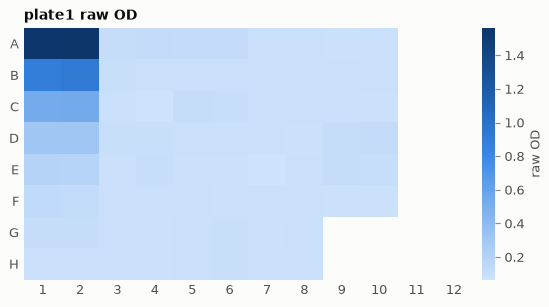

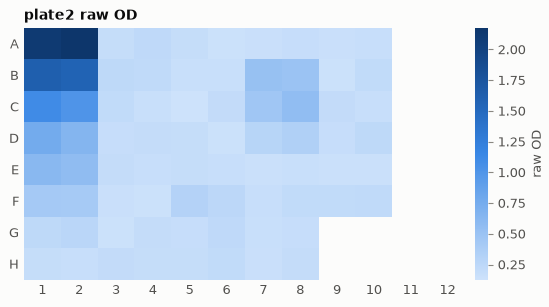

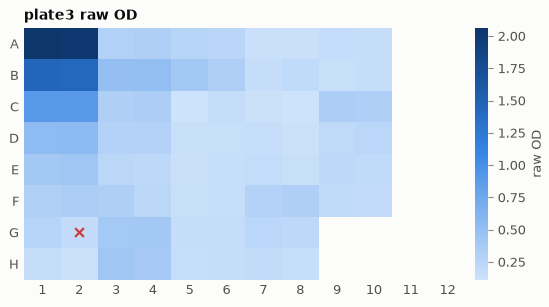

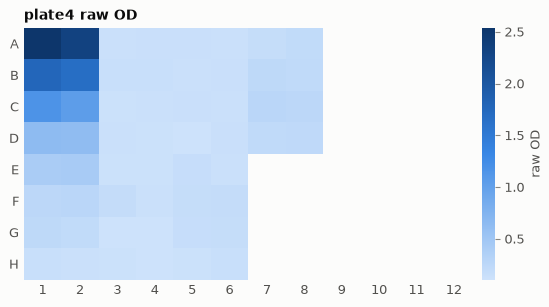

In [3]:
cfg = PipelineConfig(normalize=False)
result = run_pipeline(base / "manifest.csv", cfg)
for pid in ["plate1", "plate2", "plate3", "plate4"]:
    show(P.plot_plate_heatmap(result.wells[result.wells.plate_id == pid], title=f"{pid} raw OD"))

## 2 · Standard curves: weighted 4PL vs the authors' straight lines

Every plate is fitted with a 4PL and a 5PL by weighted least squares, with weights 1/OD² on the
*gross* signal. The zero standard is included as a calibrator at x = 0. The 5PL is kept only if
it lowers AICc by more than 2. Here it never does, so all four plates use the 4PL.

In [4]:
curves = result.curve_table()
curves[
    [
        "plate_id",
        "model",
        "a",
        "a_se",
        "b",
        "b_se",
        "c",
        "c_se",
        "d",
        "d_se",
        "r_squared",
        "aicc_4pl",
        "aicc_5pl",
    ]
]

,plate_id,model,a,a_se,b,b_se,c,c_se,d,d_se,r_squared,aicc_4pl,aicc_5pl
0,plate1,4pl,-1.087e-03,0.002,1.100,0.031,862.571,197.408,4.113,0.684,0.999,-165.803,-161.776
1,plate2,4pl,-6.018e-03,0.013,0.864,0.106,453.535,357.595,3.726,1.442,0.993,-96.274,-92.234
2,plate3,4pl,2.730e-04,0.008,0.780,0.085,2145.532,3470.312,7.724,6.997,0.996,-102.842,-99.423
3,plate4,4pl,4.839e-04,0.006,1.025,0.059,436.206,143.209,4.319,0.822,0.996,-122.256,-118.360


The authors' linear calibrations, as typed in the workbook, were `conc = (OD − a) / b`:

| plate | a | b | response used |
|---|---|---|---|
| 1 | 0.0032 | 0.0030 | OD − blank (H9/H10) |
| 2 | 0.0097 | 0.0144 | OD − blank (H9/H10) |
| 3 | 0.1167 | 0.0104 | raw OD |
| 4 | 0.1038 | 0.0103 | raw OD |

Both calibrations can be applied to the *standards themselves*. Back-calculating the standards
and comparing them with their nominal values (% recovery) is the direct test of a calibration.

In [5]:
LINEAR = {
    "plate1": (0.0032, 0.0030, "net"),
    "plate2": (0.0097, 0.0144, "net"),
    "plate3": (0.1167, 0.0104, "raw"),
    "plate4": (0.1038, 0.0103, "raw"),
}
AUTHOR_BLANK = {"plate1": ["H9", "H10"], "plate2": ["H9", "H10"]}
plates_raw = {
    pid: pd.read_csv(base / f"plates/{pid}.csv", skiprows=3, index_col=0) for pid in LINEAR
}


def linear_conc(pid, od_raw):
    a, b, kind = LINEAR[pid]
    if kind == "net":
        grid = plates_raw[pid]
        blank = np.mean([grid.loc[w[0], w[1:]] for w in AUTHOR_BLANK[pid]])
        od_raw = od_raw - blank
    return (od_raw - a) / b


std = result.wells[result.wells.type == "standard"].copy()
lvl = std.groupby(["plate_id", "concentration"]).agg(od=("od", "mean")).reset_index()
lvl["linear_recovery_pct"] = [
    100 * linear_conc(p, o) / c
    for p, o, c in zip(lvl.plate_id, lvl.od, lvl.concentration, strict=True)
]
rec = result.recovery.rename(columns={"recovery_pct": "4pl_recovery_pct"})
comparison = rec.merge(lvl, on=["plate_id", "concentration"])
(
    comparison.pivot(
        index="concentration",
        columns="plate_id",
        values=["4pl_recovery_pct", "linear_recovery_pct"],
    ).round(0)
)

4pl_recovery_pct                      linear_recovery_pct  \
plate_id                plate1 plate2 plate3 plate4              plate1   
concentration                                                             
7.8                       94.0   67.0  140.0  118.0               134.0   
15.6                     100.0  132.0  115.0   92.0               126.0   
31.3                     102.0  129.0   97.0  104.0               124.0   
62.5                     100.0   92.0   85.0   96.0               121.0   
125.0                    102.0   92.0   98.0  104.0               122.0   
250.0                     97.0  104.0  111.0  103.0               111.0   
500.0                    101.0  103.0  102.0   99.0                99.0   

                                    
plate_id      plate2 plate3 plate4  
concentration                       
7.8             88.0  135.0  142.0  
15.6           117.0  128.0   99.0  
31.3            96.0   91.0   97.0  
62.5            62.0   67.0   82.0  
125.0           50.0   60.0   78.0  
250.0           40.0   51.0   63.0  
500.0           28.0   37.0   45.0

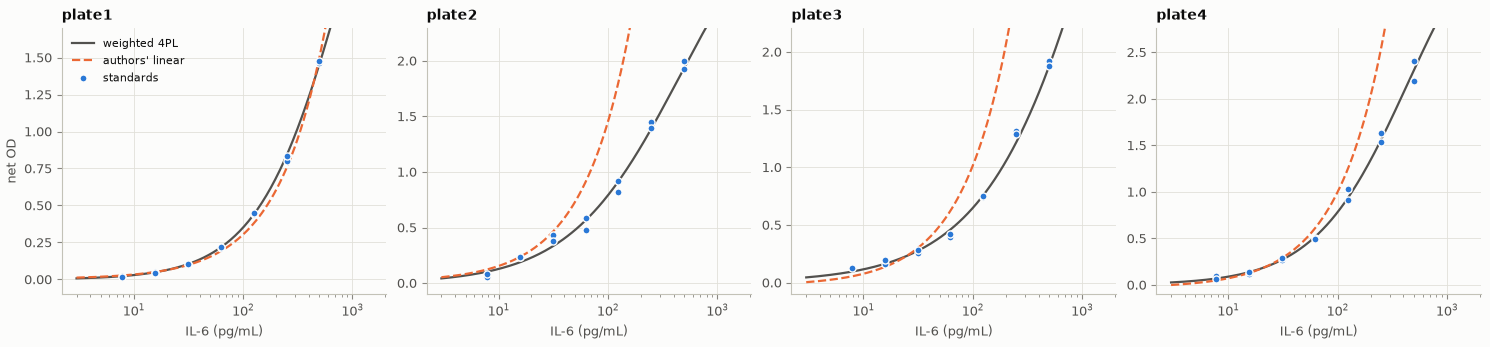

In [6]:
with P.style():
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=False)
    for ax, pid in zip(axes, LINEAR, strict=True):
        fit = result.fits[(pid, "IL-6")]
        s = std[(std.plate_id == pid) & ~std.outlier]
        xs = np.geomspace(3, 1500, 200)
        ax.plot(xs, fit.predict(xs), color=P.INK_2, lw=1.6, label="weighted 4PL")
        a, b, kind = LINEAR[pid]
        blank_ours = s["blank_mean"].iloc[0]
        shift = 0.0 if kind == "net" else blank_ours
        ax.plot(xs, a + b * xs - shift, color=P.SERIES[1], lw=1.6, ls="--", label="authors' linear")
        ax.scatter(
            s.concentration,
            s.od_net,
            s=26,
            color=P.SERIES[0],
            edgecolor=P.SURFACE,
            zorder=3,
            label="standards",
        )
        ax.set_xscale("log")
        ax.set_ylim(-0.1, max(s.od_net) * 1.15)
        ax.set_title(pid)
        ax.set_xlabel("IL-6 (pg/mL)")
    axes[0].set_ylabel("net OD")
    axes[0].legend(loc="upper left")
    fig.tight_layout()

**Reading the comparison.**

* **4PL.** On plate 1 every standard recovers within 94–102%. On plates 3 and 4, every standard
  from 15.6 pg/mL up recovers within ±15%, and only the lowest level misses (140% and 118%). On
  plate 2 the three lowest levels are off (67–132%), which is why that plate fails below.
* **Linear.** The straight lines are good only over the part of the range they were
  (apparently) fitted to. Even on plate 1 the line over-recovers the lowest four standards by
  21–34%. On plates 2–4 the lines fit the bottom of the curve: they recover 88–142% at
  7.8–31 pg/mL, then collapse to 28–45% at 500 pg/mL. For these samples, which all sit at the
  bottom of the curve, that part of the error matters less than it might seem. But the fit is
  ±20–40% even there, and the lines extend below the lowest standard, where most samples fall.
* A sigmoid is the right model for a saturable binding assay. A straight line is at best a
  local approximation, and its validity range has to be demonstrated, not assumed.

## 3 · QC: which plates pass, and what range is quantifiable?

In [7]:
result.plate_qc[
    ["plate_id", "passed", "r_squared", "std_levels_pass", "lod", "lloq", "uloq", "reasons"]
]

,plate_id,passed,r_squared,std_levels_pass,lod,lloq,uloq,reasons
0,plate1,True,0.999,7/7,5.552,7.8,500.0,
1,plate2,False,0.993,4/7,3.019,62.5,500.0,only 4/7 standard levels pass
2,plate3,True,0.996,6/7,4.801,15.6,500.0,
3,plate4,True,0.996,6/7,4.071,15.6,500.0,


In [8]:
result.wells.loc[
    result.wells.outlier, ["plate_id", "well", "type", "sample_id", "od", "outlier_reason"]
]

,plate_id,well,type,sample_id,od,outlier_reason
213,plate3,G2,standard,STD7,0.185,standard pair CV > 20% and deletion residual 1...


* **Plate 2 fails** acceptance: only 4 of 7 standard levels meet the criteria (the rule needs
  ≥ 75%). Its quantification range is 62.5–500 pg/mL, 8× narrower at the low end than plate 1's.
* Plates 1, 3 and 4 pass, with LLOQs of 7.8–15.6 pg/mL. The LOD (blank mean + 3 SD) is about
  3–6 pg/mL. It is estimated from only two zero-standard wells per plate, so treat it as an
  order of magnitude.
* One standard well (plate 3, G2) is excluded as a gross error by the leave-one-out residual
  screen.

## 4 · Where do the samples fall relative to the validated range?

In [9]:
res = result.results.merge(info[["sample_id", "treatment", "time_h", "plate"]], on="sample_id")
res = res.merge(authors, on="sample_id")
order = sorted(res.group.unique(), key=lambda g: (int(g.split()[1][:-1]), g.split()[0] == "ASF"))
summary = (
    res.groupby("group")
    .agg(
        plate=("plate", "first"),
        n=("sample_id", "size"),
        quantifiable=("censor", lambda c: int((c == "").sum())),
        below_lloq=("censor", lambda c: int((c == "<LLOQ").sum())),
        authors_median=("authors_conc", "median"),
        pipeline_median_extrapolated=("conc_extrap", "median"),
    )
    .reindex(order)
)
summary

,plate,n,quantifiable,below_lloq,authors_median,pipeline_median_extrapolated
group,,,,,,
NSF 0h,1,10,1,8,3.833,8.444
NSF 1h,1,10,0,10,2.433,2.110
ASF 1h,1,10,0,9,1.933,7.905
NSF 2h,2,10,0,10,2.920,1.772
ASF 2h,2,10,0,10,3.441,8.882
NSF 6h,2,10,0,10,2.312,2.036
ASF 6h,3,10,5,4,27.024,26.585
NSF 12h,3,10,0,10,3.894,0.824
ASF 12h,3,10,1,9,16.389,8.421


Spearman ρ = 0.90; 100/110 samples below LLOQ


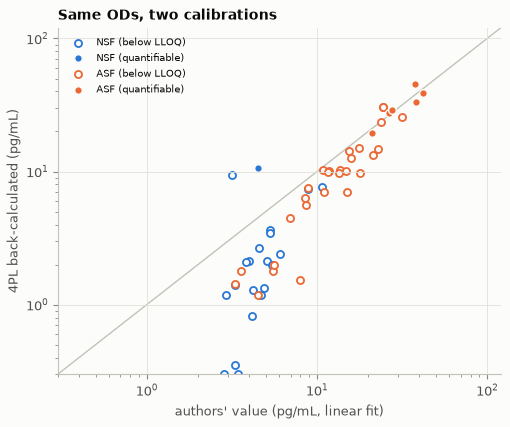

In [10]:
with P.style():
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    for i, t in enumerate(["NSF", "ASF"]):
        d = res[res.treatment == t]
        q = d.censor.eq("")
        ax.scatter(
            d.authors_conc[~q].clip(lower=0.3),
            d.conc_extrap[~q].clip(lower=0.3),
            s=26,
            facecolor=P.SURFACE,
            edgecolor=P.SERIES[i],
            linewidth=1.3,
            label=f"{t} (below LLOQ)",
        )
        ax.scatter(
            d.authors_conc[q],
            d.conc_extrap[q],
            s=30,
            color=P.SERIES[i],
            edgecolor=P.SURFACE,
            label=f"{t} (quantifiable)",
        )
    lim = [0.3, 120]
    ax.plot(lim, lim, color=P.AXIS, lw=1, zorder=0)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("authors' value (pg/mL, linear fit)")
    ax.set_ylabel("4PL back-calculated (pg/mL)")
    ax.set_title("Same ODs, two calibrations")
    ax.legend(loc="upper left", fontsize=7.5)
    fig.tight_layout()
print(
    f"Spearman ρ = {res[['authors_conc', 'conc_extrap']].corr('spearman').iloc[0, 1]:.2f}; "
    f"{int(res.censor.eq('<LLOQ').sum())}/{len(res)} samples below LLOQ"
)

**Most samples (100 of 110) are below the LLOQ.** Only ASF 6 h has several samples in the validated
range (5 of 10). Healthy mouse serum IL-6 normally sits at a few pg/mL, near or below the
sensitivity of this kit, so this is biologically expected. It does mean that most of the numbers
reported for these groups are **extrapolations below the lowest standard**, where neither
calibration has been validated.

The two calibrations agree on the ordering of samples (Spearman ρ above). They disagree on
magnitude, most of all at the bottom. Samples reading at or below the zero standard have no
defined 4PL concentration, and the plot clips them to its lower edge. The authors' linear fits
turn the same wells into values of 1–10 pg/mL, or into hand-entered zeros.

## 5 · Statistics: a strict analysis, then a labelled sensitivity analysis

For each time point with both treatments (1–24 h), ASF is compared with NSF. The pipeline
checks normality (Shapiro-Wilk on log10 values) and picks Welch's t-test or Mann-Whitney. The
five p-values are then **Benjamini-Hochberg-adjusted across time points**.

**(A) Strict, as the pipeline does by default.** Plates that fail QC are excluded. Values below
LLOQ are censored at one **study-wide** limit, so no comparison depends on which plate a sample
happened to be on.

In [11]:
def by_timepoint(cfg, frame=res, qc=result.plate_qc):
    data = st.prepare_values(frame, qc, cfg)
    data = data[data.time_h > 0].copy()
    data["analyte"] = data.time_h.map(lambda t: f"{t} h")
    data["group"] = data.treatment
    out = st.compare_groups(data, cfg, group_order=["NSF", "ASF"])
    return data, out.omnibus.set_index("analyte")


strict_cfg = st.StatsConfig(value_col="conc")
strict_data, strict = by_timepoint(strict_cfg)
display(strict_data.handling.value_counts().rename("samples"))
strict[["test", "note", "p", "p_adj_bh"]]

handling
substituted: below common LLOQ 46.8 → /1.41    68
excluded: plate failed QC                      30
excluded: cv_fail                               2
Name: samples, dtype: int64

,test,note,p,p_adj_bh
analyte,,,,
1 h,not tested,all values identical (e.g. all censored at the...,NaN,NaN
2 h,not tested,fewer than two groups with n >= 2,NaN,NaN
6 h,not tested,fewer than two groups with n >= 2,NaN,NaN
12 h,not tested,all values identical (e.g. all censored at the...,NaN,NaN
24 h,not tested,all values identical (e.g. all censored at the...,NaN,NaN


At validated precision **the data cannot distinguish the groups.** Plate 2 (2 h and NSF 6 h)
is excluded. After harmonisation, *every* remaining value is below the study-wide LLOQ
(46.8 pg/mL, which is 15.6 pg/mL × the 3× dilution used for some 0 h samples), so every value ties
at that limit and no comparison can be tested at all. The 6 h contrast cannot even be formed, because its
control group sits on the failed plate. This is not a failure of the pipeline. It is the correct
answer to the question "what does this assay support quantitatively?"

**(B) Sensitivity analysis: treat sub-LLOQ back-calculated values as data.** This is effectively
what the original analysis did. All plates are used. A value below LLOQ becomes its 4PL
back-calculation. A sample below the curve floor, where no concentration exists, is ranked
lowest. Because those floor substitutions are arbitrary numbers, only **rank-based** inference is
meaningful here. The comparison uses the Mann-Whitney p-value and the rank-biserial correlation
*r*. Fold changes are not used: the substituted floor values make any ratio meaningless.

In [12]:
sens_cfg = st.StatsConfig(value_col="conc", exclude_failed_plates=False, censored="extrapolate")
sens_data, _ = by_timepoint(sens_cfg)
display(sens_data.handling.value_counts().rename("samples"))

rows = []
for t in (1, 2, 6, 12, 24):
    d = sens_data[sens_data.time_h == t]
    x = d.loc[d.treatment == "NSF", "value"].dropna()
    y = d.loc[d.treatment == "ASF", "value"].dropna()
    u = mannwhitneyu(y, x, alternative="two-sided")
    rows.append(
        {
            "time": f"{t} h",
            "n_NSF": len(x),
            "n_ASF": len(y),
            "median_NSF": x.median(),
            "median_ASF": y.median(),
            "rank_biserial_r": 2 * u.statistic / (len(x) * len(y)) - 1,
            "p": u.pvalue,
        }
    )
sens = pd.DataFrame(rows)
sens["p_BH"] = multipletests(sens.p, method="fdr_bh")[1]
sens

handling
below curve floor → lowest rank (min/2)          49
extrapolated: <LLOQ (outside validated range)    43
measured                                          6
excluded: cv_fail                                 2
Name: samples, dtype: int64

,time,n_NSF,n_ASF,median_NSF,median_ASF,rank_biserial_r,p,p_BH
0,1 h,10,9,0.047,0.047,-0.178,3.906e-01,0.391
1,2 h,10,10,0.047,1.599,0.360,1.575e-01,0.197
2,6 h,10,9,0.047,27.460,1.000,2.238e-04,0.001
3,12 h,10,10,0.071,8.421,0.900,7.003e-04,0.002
4,24 h,10,10,0.047,5.442,0.560,1.472e-02,0.025


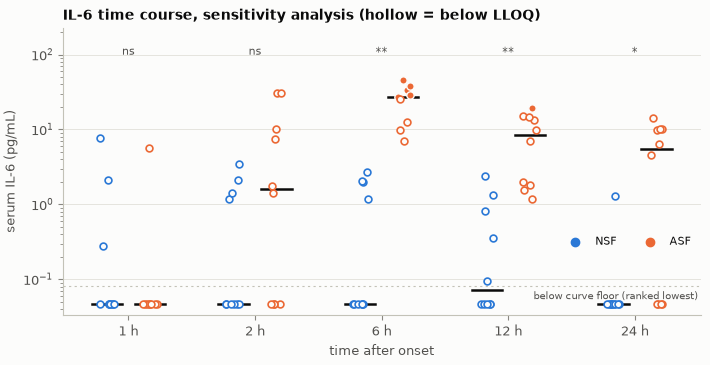

In [13]:
with P.style():
    fig, ax = plt.subplots(figsize=(7.2, 3.8))
    times = [1, 2, 6, 12, 24]
    for i, t in enumerate(["NSF", "ASF"]):
        d = sens_data[sens_data.treatment == t]
        rng = np.random.default_rng(i)
        for k, tp in enumerate(times):
            v = d[d.time_h == tp]
            x = k + (-0.17 if t == "NSF" else 0.17) + rng.uniform(-0.06, 0.06, len(v))
            measured = v.handling.eq("measured").to_numpy()
            ax.scatter(
                x[measured],
                v.value[measured],
                s=28,
                color=P.SERIES[i],
                edgecolor=P.SURFACE,
                zorder=3,
            )
            ax.scatter(
                x[~measured],
                v.value[~measured],
                s=24,
                facecolor=P.SURFACE,
                edgecolor=P.SERIES[i],
                linewidth=1.2,
                zorder=3,
            )
            ax.plot(
                [
                    k + (-0.17 if t == "NSF" else 0.17) - 0.12,
                    k + (-0.17 if t == "NSF" else 0.17) + 0.12,
                ],
                [v.value.median()] * 2,
                color=P.INK,
                lw=1.8,
            )
        ax.scatter([], [], color=P.SERIES[i], label=t)
    top = sens_data.value.max()
    floor = sens_data.loc[sens_data.handling.str.startswith("below curve floor"), "value"].max()
    for k, r in enumerate(sens.itertuples()):
        star = (
            "***" if r.p_BH < 0.001 else "**" if r.p_BH < 0.01 else "*" if r.p_BH < 0.05 else "ns"
        )
        ax.text(k, top * 2.2, star, ha="center", fontsize=8, color=P.INK_2)
    ax.axhline(floor * 1.7, color=P.AXIS, lw=0.8, ls=(0, (2, 3)))
    ax.text(
        len(times) - 0.5,
        floor * 1.25,
        "below curve floor (ranked lowest)",
        ha="right",
        va="center",
        fontsize=7,
        color=P.INK_2,
    )
    ax.set_yscale("log")
    ax.set_ylim(top=top * 5)
    ax.set_xticks(range(len(times)), [f"{t} h" for t in times])
    ax.set_ylabel("serum IL-6 (pg/mL)")
    ax.set_xlabel("time after onset")
    ax.set_title("IL-6 time course, sensitivity analysis (hollow = below LLOQ)")
    ax.legend(loc="lower right", bbox_to_anchor=(1, 0.2), ncol=2)
    ax.grid(axis="x", visible=False)
    fig.tight_layout()

## 6 · Biological interpretation

**What survives.**

* **Ordering.** Under the sensitivity analysis, IL-6 in ASF mice ranks above time-matched NSF
  controls at **6, 12 and 24 h**. Here the rank-biserial *r* is large and the BH-adjusted p is
  below 0.05. There is no difference at 1–2 h. This matches the authors' qualitative story: a
  systemic IL-6 response that appears a few hours after fragmentation begins and persists
  through 24 h.
* **Peak.** ASF 6 h is the only group with a substantial share of samples (5/10, median
  ≈ 27 pg/mL) inside the validated quantification range, so it is the one *quantitative* result
  the assay supports. It is consistent with the authors' ≈ 27 pg/mL. IL-6 peaking hours after an
  inflammatory stimulus is typical of a cytokine cascade. Stress-axis and sympathetic activation
  drive innate-immune cells (and adipose tissue) to secrete IL-6, which then induces the hepatic
  acute-phase response. This fits the paper's conclusion that inflammation from sleep
  fragmentation starts in the periphery.

**What does not survive.**

* **Fold changes.** Fold changes such as "11× at 6 h" or "3× at 24 h" are ratios of
  sub-LLOQ extrapolations. Most control values sit at or below the zero standard, so a ratio
  against them is not a measurement.
* **The 6 h magnitude.** The 6 h comparison crosses plates, and the control plate failed QC.
  Without bridge samples, part of that difference could be calibration.
* **Strict-criteria significance.** Under the strict criteria (A), none of the differences can
  be established.

**How the experiment could be improved.**

1. Use a high-sensitivity IL-6 assay, such as an electrochemiluminescence or Simoa platform with
   an LLOQ below 1 pg/mL, or run serum neat rather than diluted, so that baseline levels are
   quantifiable.
2. **Randomise groups across plates**, never whole groups per plate, and include the same pooled
   serum as a bridge control on every plate. Then `immunoassay.normalize` can remove plate
   effects instead of leaving them confounded with treatment.
3. Pre-specify the censoring policy (substitution, or a Tobit/interval-censored model) instead of
   hand-entering zeros.

*Everything above is regenerated by `python scripts/build_notebooks.py`.*